# Classification SCI vs NON-SCI

Classification binaire de tweets : Science (SCI) vs Non-Science (NON-SCI).

L'objectif est de construire un pipeline de classification complet, depuis le prétraitement des textes jusqu'à l'évaluation finale sur un jeu de test.




## 1. Imports et configuration

On importe l'ensemble des bibliothèques nécessaires au pipeline :
- **NLP** : `nltk` et `spacy` pour le prétraitement des textes (tokenisation, lemmatisation, analyse grammaticale)
- **Vectorisation** : `TfidfVectorizer` de scikit-learn
- **Classifieurs** : Naive Bayes, Régression Logistique, SVM, k-NN, Forêt Aléatoire
- **Déséquilibre de classes** : `imbalanced-learn` (SMOTE, sur- et sous-échantillonnage)
- **Optimisation des hyperparamètres** : `optuna`


In [21]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import re, copy, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import word_tokenize
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
stop_words = set(stopwords.words('english'))

import spacy
import contractions
import emoji

# scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_score, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.preprocessing import MaxAbsScaler
from sklearn.base import clone

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score

# imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
print('Imports OK')


Imports OK


## 2. Chargement et exploration

Le jeu de données `scitweets_export.tsv` contient 1 140 tweets annotés. La variable cible est `science_related` (0 = Non-Scientifique, 1 = Scientifique).

Avant toute modélisation, il est indispensable d'analyser la répartition des classes. Un déséquilibre prononcé modifie en effet la stratégie d'apprentissage et le choix de la métrique d'évaluation.


In [22]:
data_raw = pd.read_csv('scitweets_export.tsv', sep='\t', index_col=0)
print(f'Forme : {data_raw.shape}')
print(f'Colonnes : {list(data_raw.columns)}')
data_raw.head()


Forme : (1140, 6)
Colonnes : ['tweet_id', 'text', 'science_related', 'scientific_claim', 'scientific_reference', 'scientific_context']


,tweet_id,text,science_related,scientific_claim,scientific_reference,scientific_context
0,316669998137483264,Knees are a bit sore. i guess that's a sign th...,0,0.0,0.0,0.0
1,319090866545385472,McDonald's breakfast stop then the gym 🏀💪,0,0.0,0.0,0.0
2,322030931022065664,Can any Gynecologist with Cancer Experience ex...,1,1.0,0.0,0.0
3,322694830620807168,Couch-lock highs lead to sleeping in the couch...,1,1.0,0.0,0.0
4,328524426658328576,Does daily routine help prevent problems with ...,1,1.0,0.0,0.0


Distribution des classes :
  Non-Scientific : 765 échantillons (67.1%)
  Scientific : 375 échantillons (32.9%)


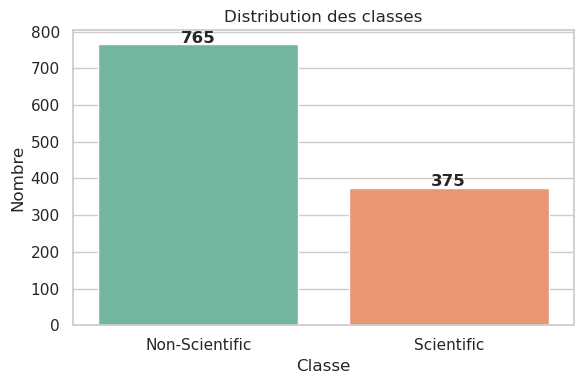


Ratio de déséquilibre : 2.04
→ Déséquilibre modéré (~2:1). Plusieurs stratégies testées à l'étape 8.


In [23]:
target_col = 'science_related'
counts = data_raw[target_col].value_counts().sort_index()
ratio  = counts / counts.sum()

print('Distribution des classes :')
for label, n in counts.items():
    name = 'Non-Scientific' if label == 0 else 'Scientific'
    print(f'  {name} : {n} échantillons ({ratio[label]*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Non-Scientific', 'Scientific'], y=counts.values, palette='Set2', ax=ax)
ax.set_title('Distribution des classes')
ax.set_xlabel('Classe'); ax.set_ylabel('Nombre')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

imbalance = counts.max() / counts.min()
print(f'\nRatio de déséquilibre : {imbalance:.2f}')
print('→ Déséquilibre modéré (~2:1). Plusieurs stratégies testées à l\'étape 8.')


## 3. Prétraitement du texte

Le prétraitement est appliqué **une seule fois sur l'ensemble du corpus**, avant la séparation apprentissage/test. Cette approche est valide ici car les deux pipelines sont entièrement non supervisés : ils n'utilisent aucune information sur les classes.

On compare deux stratégies de prétraitement :

- **P1 (NLTK)** : passage en minuscules, suppression des URLs, hashtags, mentions et emojis, filtrage des stopwords, lemmatisation WordNet.
- **P2 (spaCy)** : expansion des contractions, encodage des entités nommées (URLs, personnes, nombres, emojis) en tokens spéciaux, lemmatisation filtrée par partie du discours (noms, verbes, adjectifs et adverbes uniquement), liste noire corpus-spécifique.

L'hypothèse est que P2, en filtrant par catégorie grammaticale, produit une représentation plus informative pour distinguer les tweets scientifiques des autres.


In [24]:
# ═══════════════════════════════════════════════════
# P1
# ═══════════════════════════════════════════════════
def clean_social_p1(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = emoji.replace_emoji(text, replace=' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def tokenize_and_clean(text):
    sentence = re.sub(r'[^\w\s]', ' ', text)
    sentence = re.sub(r'\s+[a-zA-Z]\s+', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    tokens = word_tokenize(sentence)
    tokens = [t.lower() for t in tokens]
    table  = str.maketrans('', '', string.punctuation)
    words  = [t.translate(table) for t in tokens if t.translate(table).isalnum()]
    words  = [w for w in words if not w.isdigit()]
    words  = [w for w in words if w not in stop_words]
    lem    = WordNetLemmatizer()
    words  = [lem.lemmatize(w) for w in words]
    return ' '.join(words)

def preprocess_p1(text):
    return tokenize_and_clean(clean_social_p1(text))

# ═══════════════════════════════════════════════════
# P2
# ═══════════════════════════════════════════════════
nlp = spacy.load('en_core_web_sm', disable=['parser'])

P2_BLACKLIST = {'eurekamag'}
P2_PLACEHOLDERS = {'url', 'emoticon', 'person', 'number'}

def format_p2(txt):
    txt = contractions.fix(str(txt))
    txt = re.sub(r'#(\w+)', r' \1 ', txt)
    txt = re.sub(r'@[\w_]+', ' person ', txt)
    txt = re.sub(r'http\S+|www\S+', ' url ', txt)
    txt = emoji.replace_emoji(txt, replace=' emoticon ')
    doc = nlp(txt)
    new_txt = txt
    for ent in reversed(doc.ents):
        if ent.label_ in ['CARDINAL', 'PERCENT', 'MONEY']:
            new_txt = new_txt[:ent.start_char] + ' number ' + new_txt[ent.end_char:]
    return new_txt

VALID_POS = {'ADJ', 'ADV', 'NOUN', 'PROPN', 'VERB'}

def preprocess_p2(text):
    txt = format_p2(text)
    doc = nlp(txt)
    tokens = [
        tok.lemma_.lower() for tok in doc
        if tok.is_alpha
        and (tok.pos_ in VALID_POS or tok.lemma_.lower() in P2_PLACEHOLDERS)
        and tok.lemma_.lower() not in P2_BLACKLIST
    ]
    return ' '.join(tokens)

# ═══════════════════════════════════════════════════
# Application sur le corpus
# ═══════════════════════════════════════════════════
print('P1 ...')
data_raw['tokens_p1'] = data_raw['text'].apply(preprocess_p1)
print('P2  — peut prendre 1-2 min...')
data_raw['tokens_p2'] = data_raw['text'].apply(preprocess_p2)

mask_valid = (
    data_raw['tokens_p1'].str.strip().ne('') &
    data_raw['tokens_p2'].str.strip().ne('')
)
data = data_raw[mask_valid].copy().reset_index(drop=True)
print(f'\nLignes conservées : {len(data)} / {len(data_raw)}')



P1 ...
P2  — peut prendre 1-2 min...

Lignes conservées : 1139 / 1140


P1 vocab: 1940 | P2 vocab: 2030

Silhouette score (cosine, n=1139):
  P1 (NLTK)  : 0.0041
  P2 (spaCy) : 0.0047


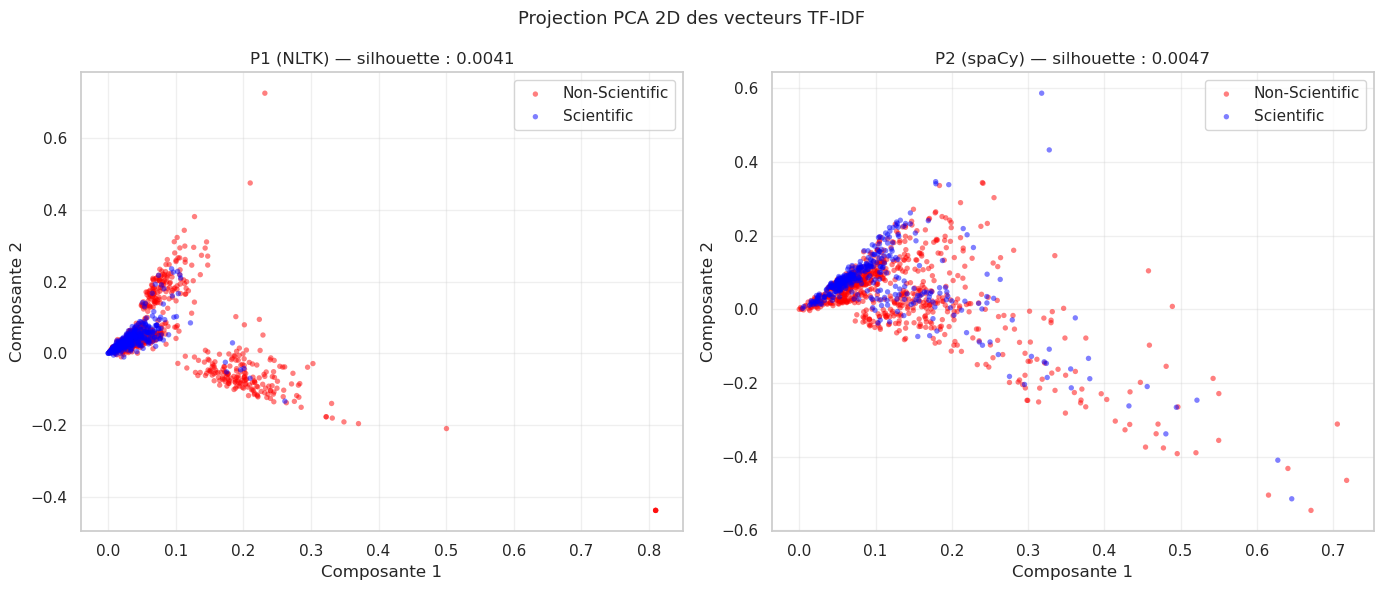

<Figure size 640x480 with 0 Axes>


→ Meilleure séparation : P2  (Δ = 0.0006)


In [25]:


y = data['science_related'].values

# ═══════════════════════════════════════════════════
# Vectorize both versions identically
# ═══════════════════════════════════════════════════
def vectorize(texts):
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9,
                          sublinear_tf=True)
    return vec.fit_transform(texts)

X_p1 = vectorize(data['tokens_p1'])
X_p2 = vectorize(data['tokens_p2'])
print(f'P1 vocab: {X_p1.shape[1]} | P2 vocab: {X_p2.shape[1]}')

# ═══════════════════════════════════════════════════
# Silhouette score on the full set (corpus is small)
# ═══════════════════════════════════════════════════
sil_p1 = silhouette_score(X_p1, y, metric='cosine')
sil_p2 = silhouette_score(X_p2, y, metric='cosine')

print(f'\nSilhouette score (cosine, n={len(y)}):')
print(f'  P1 (NLTK)  : {sil_p1:.4f}')
print(f'  P2 (spaCy) : {sil_p2:.4f}')

# ═══════════════════════════════════════════════════
# 3-component SVD
# ═══════════════════════════════════════════════════
svd_p1 = TruncatedSVD(n_components=3, random_state=42).fit_transform(X_p1)
svd_p2 = TruncatedSVD(n_components=3, random_state=42).fit_transform(X_p2)

colors = {0: 'red', 1: 'blue'}
labels = {0: 'Non-Scientific', 1: 'Scientific'}

# ═══════════════════════════════════════════════════
# 2D plots
# ═══════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coords, sil, name in [
    (axes[0], svd_p1, sil_p1, 'P1 (NLTK)'),
    (axes[1], svd_p2, sil_p2, 'P2 (spaCy)'),
]:
    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=colors[cls], label=labels[cls],
                   alpha=0.5, s=15, edgecolors='none')
    ax.set_title(f'{name} — silhouette : {sil:.4f}')
    ax.set_xlabel('Composante 1')
    ax.set_ylabel('Composante 2')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Projection PCA 2D des vecteurs TF-IDF', fontsize=13)
plt.tight_layout()
plt.show()



plt.suptitle('Projection PCA 3D des vecteurs TF-IDF', fontsize=13)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════
# Verdict
# ═══════════════════════════════════════════════════
winner = 'P2 ' if sil_p2 > sil_p1 else 'P1 '
delta = abs(sil_p2 - sil_p1)
print(f'\n→ Meilleure séparation : {winner} (Δ = {delta:.4f})')

## 4. Séparation apprentissage / test stratifiée

On sépare le jeu de données en **80 % pour l'apprentissage** et **20 % pour le test**, avec stratification sur la variable cible.

La stratification garantit que la proportion de tweets scientifiques est identique dans les deux sous-ensembles, ce qui est important avec un déséquilibre de classes.

 **Attention**  
Le jeu de test est mis de côté immédiatement. Il ne sera utilisé qu'une seule fois, à l'étape 9, pour l'évaluation finale. Toutes les décisions (choix du prétraitement, du classifieur, des hyperparamètres) sont prises uniquement à partir du jeu d'apprentissage, via validation croisée.


In [26]:
y    = data[target_col].values
X_p1 = data['tokens_p1'].values
X_p2 = data['tokens_p2'].values

indices = np.arange(len(data))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_p1_train, X_p1_test = X_p1[idx_train], X_p1[idx_test]
X_p2_train, X_p2_test = X_p2[idx_train], X_p2[idx_test]
y_train, y_test        = y[idx_train],    y[idx_test]

print(f'Train : {len(y_train)} | Test : {len(y_test)}')
print(f'Distribution train : {np.bincount(y_train)} (NON-SCI / SCI)')
print(f'Distribution test  : {np.bincount(y_test)}')
print(f'Ratio SCI train    : {y_train.mean():.3f}')
print(f'Ratio SCI test     : {y_test.mean():.3f} ← stratification OK')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


Train : 911 | Test : 228
Distribution train : [612 299] (NON-SCI / SCI)
Distribution test  : [153  75]
Ratio SCI train    : 0.328
Ratio SCI test     : 0.329 ← stratification OK


## 5. Comparaison P1 vs P2

Pour choisir le meilleur prétraitement, on évalue les deux pipelines sur les mêmes cinq classifieurs en validation croisée stratifiée à 5 folds.

On utilise le **F1-score** comme métrique principale plutôt que l'accuracy. En effet, avec un déséquilibre de classes (~67 % NON-SCI / ~33 % SCI), l'accuracy peut être trompeuse : un classifieur qui prédit systématiquement la classe majoritaire obtiendrait 67 % d'accuracy sans jamais détecter un tweet scientifique.

> **Remarque**  
> À cette étape exploratoire, `class_weight='balanced'` est appliqué par défaut pour rendre les classifieurs comparables entre eux, indépendamment de la stratégie de rééchantillonnage qui sera optimisée à l'étape 7.

La projection TF-IDF en 2D/3D par SVD tronquée (réalisée en amont) a fourni un premier indice visuel via le score de silhouette cosinus. P2 obtient un score légèrement supérieur (0,0047 vs 0,0041), ce qui suggère une meilleure séparation des classes dans l'espace vectoriel.

**Rappel sur les métriques :**

| Métrique | Description |
|----------|-------------|
| **Accuracy** | Proportion de prédictions correctes sur l'ensemble des tweets |
| **Précision** | Parmi les tweets prédits SCI, proportion réellement scientifiques — mesure la fiabilité des prédictions positives |
| **Rappel** | Parmi les tweets réellement SCI, proportion correctement détectée — mesure la capacité à ne pas manquer de tweets scientifiques |
| **F1-score** | Moyenne harmonique entre précision et rappel — métrique robuste pour les données déséquilibrées |


In [27]:
def make_tfidf_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=None, ngram_range=(1, 2),
            min_df=2, max_df=0.9, sublinear_tf=True)),
        ('clf', clf)
    ])

# Modèles de base pour comparaison P1/P2 — class_weight='balanced' par défaut
base_models_cw = {
    'Naive Bayes':         MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                              class_weight='balanced'),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=RANDOM_STATE,
                               probability=True, class_weight='balanced'),
    'K-NN':                KNeighborsClassifier(),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                  random_state=RANDOM_STATE,
                                                  n_jobs=-1, class_weight='balanced'),
}

SCORING = ['accuracy', 'precision', 'recall', 'f1']

def evaluate_models(X_text, y, dataset_name, models):
    rows = []
    for name, clf in models.items():
        pipe   = make_tfidf_pipeline(clone(clf))
        scores = cross_validate(pipe, X_text, y, cv=cv, scoring=SCORING, n_jobs=-1)
        for i in range(cv.n_splits):
            rows.append({
                'Dataset': dataset_name, 'Model': name, 'Fold': i,
                'Accuracy':  scores['test_accuracy'][i],
                'Precision': scores['test_precision'][i],
                'Recall':    scores['test_recall'][i],
                'F1':        scores['test_f1'][i],
                
            })
    return pd.DataFrame(rows)

print('Évaluation P1 — 5 modèles × 5 folds...')
res_p1 = evaluate_models(X_p1_train, y_train, 'P1', base_models_cw)
print('Évaluation P2 — 5 modèles × 5 folds...')
res_p2 = evaluate_models(X_p2_train, y_train, 'P2', base_models_cw)

results_cv = pd.concat([res_p1, res_p2], ignore_index=True)
summary = (results_cv
           .groupby(['Dataset', 'Model'])[['Accuracy','Precision','Recall','F1']]
           .agg(['mean','std']).round(3))
print('\n=== Récapitulatif (moyenne ± écart-type) ===')
print(summary)


Évaluation P1 — 5 modèles × 5 folds...
Évaluation P2 — 5 modèles × 5 folds...

=== Récapitulatif (moyenne ± écart-type) ===
                            Accuracy        Precision        Recall         \
                                mean    std      mean    std   mean    std   
Dataset Model                                                                
P1      K-NN                   0.435  0.200     0.405  0.159  0.933  0.149   
        Logistic Regression    0.787  0.021     0.665  0.043  0.716  0.032   
        Naive Bayes            0.754  0.026     0.821  0.062  0.318  0.069   
        Random Forest          0.752  0.033     0.618  0.076  0.689  0.080   
        SVM (RBF)              0.784  0.040     0.716  0.085  0.572  0.049   
P2      K-NN                   0.731  0.022     0.676  0.092  0.388  0.156   
        Logistic Regression    0.794  0.019     0.659  0.031  0.772  0.032   
        Naive Bayes            0.764  0.018     0.878  0.062  0.328  0.056   
        Random For

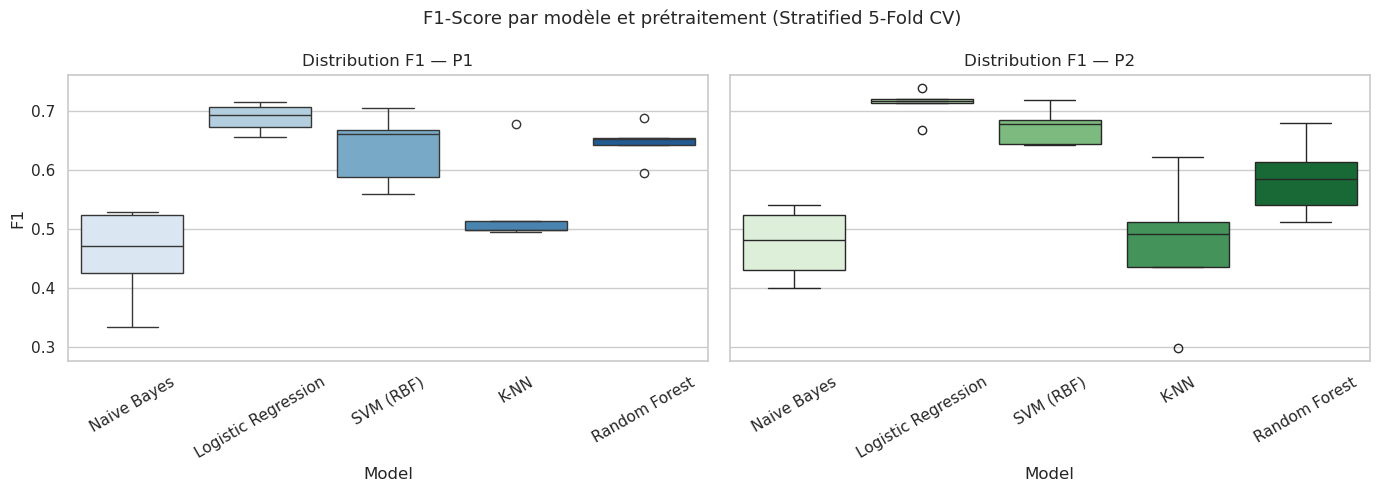

In [45]:
# Boxplots F1
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ds, palette in zip(axes, ['P1', 'P2'], ['Blues', 'Greens']):
    sns.boxplot(data=results_cv[results_cv['Dataset'] == ds],
                x='Model', y='F1', palette=palette, ax=ax)
    ax.set_title(f'Distribution F1 — {ds}')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('F1-Score par modèle et prétraitement (Stratified 5-Fold CV)', fontsize=13)
plt.tight_layout(); plt.show()


X_train_text = X_p2_train
X_test_text  = X_p2_test


**Interprétation des boxplots F1 :**

Les boxplots permettent de visualiser la **stabilité** de chaque classifieur à travers les 5 folds, au-delà de la simple moyenne.

Avec **P2** :
- La **Régression Logistique** présente la médiane la plus haute et une dispersion modérée : c'est le classifieur le plus stable et le plus performant.
- Le **SVM** affiche une médiane légèrement inférieure mais reste stable, avec peu d'outliers.
- La **Forêt Aléatoire** montre une variabilité plus importante selon les folds, signe d'une sensibilité au découpage des données.
- **Naive Bayes** a une médiane modeste mais est très rapide à entraîner : il constitue une bonne baseline.
- **K-NN** présente la plus grande dispersion, ce qui traduit une forte sensibilité aux variations d'un fold à l'autre — moins fiable pour ce type de données.




## 7. Tuning Optuna — 5 modèles (stratégie intégrée)

Au lieu de tester toutes les combinaisons d'hyperparamètres comme GridSearchCV, optuna ajuste ses essais en fonction des résultats déjà obtenus (algorithme TPE). À chaque essai, optuna appelle la fonction `objective(trial)` qui construit un pipeline complet, l'évalue en validation croisée 5-fold sur le jeu d'apprentissage, et retourne le F1 moyen. Optuna utilise ce score pour orienter les essais suivants vers les zones prometteuses de l'espace de recherche.

Le pipeline construit à chaque essai contient trois étapes : la **vectorisation TF-IDF** (avec `ngram_max` et `min_df` variables), un éventuel **rééchantillonneur** selon la stratégie choisie, et le **classifieur** avec ses hyperparamètres. Ces trois composantes sont co-optimisées simultanément, ce qui garantit que les hyperparamètres sont toujours évalués dans leurs conditions réelles d'utilisation.

Un essai Optuna explore donc en même temps :
- les hyperparamètres du classifieur (C, gamma, n_estimators...)
- les paramètres TF-IDF (ngram_max, min_df)
- la **stratégie de gestion du déséquilibre** : `original`, `class_weight`, `smote`, `downsampling`, `upsampling`, `upsampling+downsampling`

> **Remarque**  
> SMOTE est incompatible avec `MultinomialNB` car l'interpolation peut produire des valeurs négatives, ce qui viole l'hypothèse du Naive Bayes multinomial. Pour NB, les stratégies sont donc limitées à `original`, `downsampling` et `upsampling`.

**Objectif** : maximiser le F1-score en validation croisée 5-fold sur le jeu d'apprentissage uniquement.


In [29]:
tuning_results = {}
studies        = {}

def make_tfidf_step(ngram_max, min_df):
    return ('tfidf', TfidfVectorizer(
        max_features=None, ngram_range=(1, ngram_max),
        min_df=min_df, max_df=0.9, sublinear_tf=True))

def build_imb_pipeline(steps, strategy, clf):
    """
    Ajoute la stratégie de déséquilibre dans le pipeline et retourne un ImbPipeline.
    Le sampler est inséré APRÈS le TF-IDF et le scaler (opère sur les features vectorisées).
    """
    if strategy == 'smote':
        steps.append(('sampling', SMOTE(random_state=RANDOM_STATE)))
    elif strategy == 'downsampling':
        steps.append(('sampling', RandomUnderSampler(random_state=RANDOM_STATE)))
    elif strategy == 'upsampling':
        steps.append(('sampling', RandomOverSampler(random_state=RANDOM_STATE)))
    elif strategy == 'upsampling+downsampling':
        steps.append(('over',  RandomOverSampler(random_state=RANDOM_STATE)))
        steps.append(('under', RandomUnderSampler(random_state=RANDOM_STATE)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

# Stratégies disponibles par modèle
STRATS_GENERIC = ['original', 'class_weight', 'smote',
                  'downsampling', 'upsampling', 'upsampling+downsampling']
STRATS_NB      = ['original', 'downsampling', 'upsampling']  # NB : pas de class_weight ni SMOTE

print('Tuning Optuna v6 — stratégie de déséquilibre intégrée dans chaque objective')



Tuning Optuna v6 — stratégie de déséquilibre intégrée dans chaque objective


In [30]:
print('=== Tuning LogReg (80 trials) ===')

def objective_logreg(trial):
    C         = trial.suggest_float('C', 1e-3, 10, log=True)
    ngram_max = trial.suggest_categorical('ngram_max', [1,2,3])
    min_df    = trial.suggest_categorical('min_df', [2, 5])
    strategy  = trial.suggest_categorical('strategy', STRATS_GENERIC)

    cw = 'balanced' if strategy == 'class_weight' else None
    clf = LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE,
                             class_weight=cw)
    steps = [make_tfidf_step(ngram_max, min_df), ('scaler', MaxAbsScaler())]
    pipe  = build_imb_pipeline(steps, strategy, clf)
    scores = cross_val_score(pipe, X_train_text, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lr.optimize(objective_logreg, n_trials=80, show_progress_bar=True)
print(f'  Meilleur F1 CV : {study_lr.best_value:.4f}')
print(f'  Meilleurs params : {study_lr.best_params}')
tuning_results['Logistic Regression'] = {
    'best_params': study_lr.best_params, 'best_f1': study_lr.best_value}
studies['Logistic Regression'] = study_lr


=== Tuning LogReg (80 trials) ===


  0%|          | 0/80 [00:00<?, ?it/s]

  Meilleur F1 CV : 0.7103
  Meilleurs params : {'C': 0.3854669856734538, 'ngram_max': 3, 'min_df': 2, 'strategy': 'class_weight'}


In [31]:
print('=== Tuning SVM RBF (80 trials) ===')

def objective_svm(trial):
    C         = trial.suggest_float('C', 1e-2, 100, log=True)
    gamma     = trial.suggest_categorical('gamma', ['scale', 'auto'])
    ngram_max = trial.suggest_categorical('ngram_max', [1,2,3])
    strategy  = trial.suggest_categorical('strategy', STRATS_GENERIC)

    cw  = 'balanced' if strategy == 'class_weight' else None
    clf = SVC(C=C, gamma=gamma, kernel='rbf', probability=True,
              random_state=RANDOM_STATE, class_weight=cw)
    steps = [make_tfidf_step(ngram_max, 2), ('scaler', MaxAbsScaler())]
    pipe  = build_imb_pipeline(steps, strategy, clf)
    scores = cross_val_score(pipe, X_train_text, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_svm = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svm.optimize(objective_svm, n_trials=80, show_progress_bar=True)
print(f'  Meilleur F1 CV : {study_svm.best_value:.4f}')
print(f'  Meilleurs params : {study_svm.best_params}')
tuning_results['SVM (RBF)'] = {
    'best_params': study_svm.best_params, 'best_f1': study_svm.best_value}
studies['SVM (RBF)'] = study_svm


=== Tuning SVM RBF (80 trials) ===


  0%|          | 0/80 [00:00<?, ?it/s]

  Meilleur F1 CV : 0.7068
  Meilleurs params : {'C': 43.62005734158862, 'gamma': 'auto', 'ngram_max': 1, 'strategy': 'upsampling+downsampling'}


In [32]:
print('=== Tuning Random Forest (60 trials) ===')

def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth    = trial.suggest_categorical('max_depth', [None, 10, 20, 30])
    min_samples  = trial.suggest_int('min_samples_split', 2, 10)
    strategy     = trial.suggest_categorical('strategy', STRATS_GENERIC)
    ngram_max = trial.suggest_categorical('ngram_max', [1,2,3])

    cw  = 'balanced' if strategy == 'class_weight' else None
    clf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth,
        min_samples_split=min_samples,
        random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw)
    steps = [make_tfidf_step(ngram_max, 2), ('scaler', MaxAbsScaler())]
    pipe  = build_imb_pipeline(steps, strategy, clf)
    scores = cross_val_score(pipe, X_train_text, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(objective_rf, n_trials=60, show_progress_bar=True)
print(f'  Meilleur F1 CV : {study_rf.best_value:.4f}')
print(f'  Meilleurs params : {study_rf.best_params}')
tuning_results['Random Forest'] = {
    'best_params': study_rf.best_params, 'best_f1': study_rf.best_value}
studies['Random Forest'] = study_rf


=== Tuning Random Forest (60 trials) ===


  0%|          | 0/60 [00:00<?, ?it/s]

  Meilleur F1 CV : 0.6779
  Meilleurs params : {'n_estimators': 299, 'max_depth': 20, 'min_samples_split': 5, 'strategy': 'downsampling', 'ngram_max': 1}


In [33]:
print('=== Tuning K-NN (60 trials) ===')

def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 20)
    metric      = trial.suggest_categorical('metric', ['cosine', 'euclidean', 'manhattan'])
    ngram_max   = trial.suggest_categorical('ngram_max', [1, 2,3])
    strategy    = trial.suggest_categorical('strategy', STRATS_GENERIC)

    # KNN : pas de class_weight → 'class_weight' traité comme 'original'
    if strategy == 'class_weight':
        strategy = 'original'
    clf   = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
    steps = [make_tfidf_step(ngram_max, 2), ('scaler', MaxAbsScaler())]
    pipe  = build_imb_pipeline(steps, strategy, clf)
    scores = cross_val_score(pipe, X_train_text, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_knn = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_knn.optimize(objective_knn, n_trials=60, show_progress_bar=True)
print(f'  Meilleur F1 CV : {study_knn.best_value:.4f}')
print(f'  Meilleurs params : {study_knn.best_params}')
tuning_results['K-NN'] = {
    'best_params': study_knn.best_params, 'best_f1': study_knn.best_value}
studies['K-NN'] = study_knn


=== Tuning K-NN (60 trials) ===


  0%|          | 0/60 [00:00<?, ?it/s]

  Meilleur F1 CV : 0.6625
  Meilleurs params : {'n_neighbors': 18, 'metric': 'cosine', 'ngram_max': 2, 'strategy': 'upsampling'}


In [34]:
print('=== Tuning Naive Bayes (60 trials) ===')

def objective_nb(trial):
    alpha     = trial.suggest_float('alpha', 1e-3, 5.0, log=True)
    ngram_max = trial.suggest_categorical('ngram_max', [1, 2,3])
    min_df    = trial.suggest_categorical('min_df', [2, 5])
    strategy  = trial.suggest_categorical('strategy', STRATS_NB)

    # NB : pas de MaxAbsScaler, pas de class_weight, pas de SMOTE
    clf   = MultinomialNB(alpha=alpha)
    steps = [make_tfidf_step(ngram_max, min_df)]
    pipe  = build_imb_pipeline(steps, strategy, clf)
    scores = cross_val_score(pipe, X_train_text, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

study_nb = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_nb.optimize(objective_nb, n_trials=60, show_progress_bar=True)
print(f'  Meilleur F1 CV : {study_nb.best_value:.4f}')
print(f'  Meilleurs params : {study_nb.best_params}')
tuning_results['Naive Bayes'] = {
    'best_params': study_nb.best_params, 'best_f1': study_nb.best_value}
studies['Naive Bayes'] = study_nb


=== Tuning Naive Bayes (60 trials) ===


  0%|          | 0/60 [00:00<?, ?it/s]

  Meilleur F1 CV : 0.6956
  Meilleurs params : {'alpha': 3.545165261624891, 'ngram_max': 2, 'min_df': 2, 'strategy': 'upsampling'}


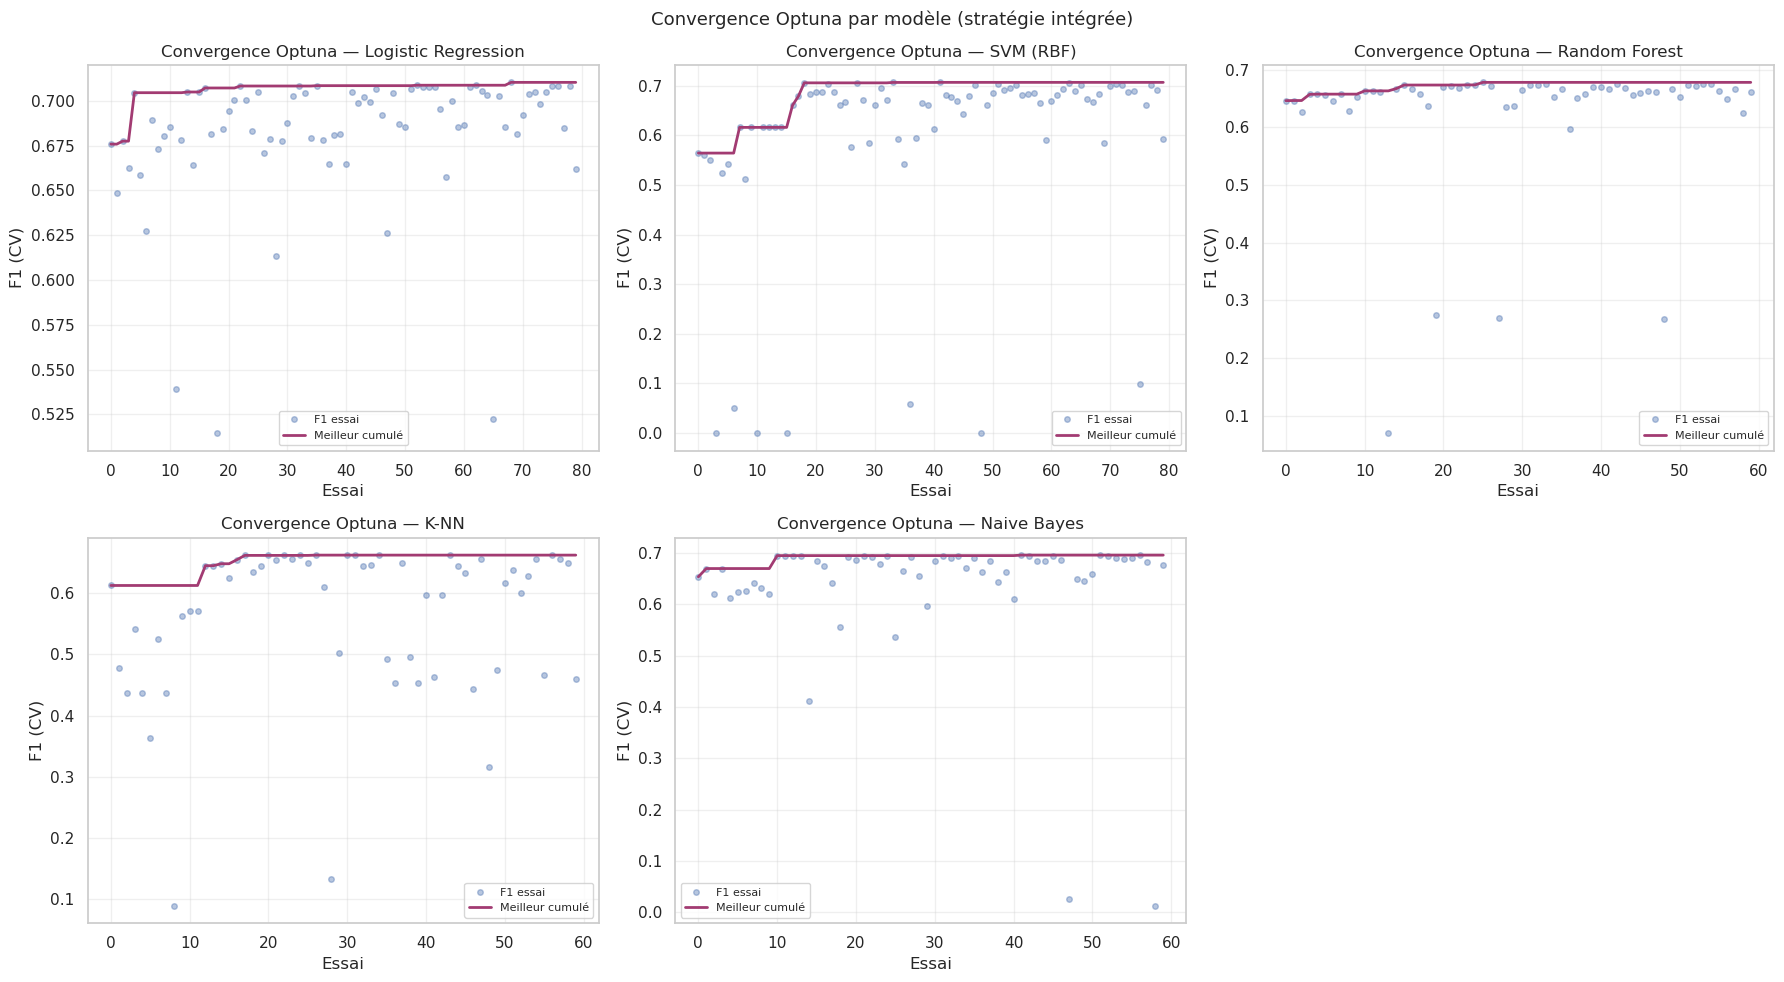


=== Résultats Optuna — 5 modèles ===
Modèle                       F1 CV  Stratégie retenue  Meilleurs params
----------------------------------------------------------------------------------------------------
  Logistic Regression     0.7103  class_weight            {'C': 0.3854669856734538, 'ngram_max': 3, 'min_df': 2, 'strategy': 'class_weight'}
  SVM (RBF)               0.7068  upsampling+downsampling  {'C': 43.62005734158862, 'gamma': 'auto', 'ngram_max': 1, 'strategy': 'upsampling+downsampling'}
  Random Forest           0.6779  downsampling            {'n_estimators': 299, 'max_depth': 20, 'min_samples_split': 5, 'strategy': 'downsampling', 'ngram_max': 1}
  K-NN                    0.6625  upsampling              {'n_neighbors': 18, 'metric': 'cosine', 'ngram_max': 2, 'strategy': 'upsampling'}
  Naive Bayes             0.6956  upsampling              {'alpha': 3.545165261624891, 'ngram_max': 2, 'min_df': 2, 'strategy': 'upsampling'}

→ Meilleur modèle : Logistic Regression
  F1

In [35]:
# Convergence Optuna
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (name, study) in zip(axes, studies.items()):
    trial_f1    = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(trial_f1)
    ax.plot(trial_f1, 'o', alpha=0.4, ms=4, color='#4C72B0', label='F1 essai')
    ax.plot(best_so_far, '-', lw=2, color='#A23B72', label='Meilleur cumulé')
    ax.set_xlabel('Essai'); ax.set_ylabel('F1 (CV)')
    ax.set_title(f'Convergence Optuna — {name}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
for ax in axes[len(studies):]:
    ax.set_visible(False)
plt.suptitle('Convergence Optuna par modèle (stratégie intégrée)', fontsize=13)
plt.tight_layout(); plt.show()

print('\n=== Résultats Optuna — 5 modèles ===')
print(f'{"Modèle":25s} {"F1 CV":>8}  Stratégie retenue  Meilleurs params')
print('-' * 100)
for m, r in tuning_results.items():
    strat = r['best_params'].get('strategy', 'N/A')
    print(f'  {m:23s} {r["best_f1"]:.4f}  {strat:22s}  {r["best_params"]}')

best_model_name = max(tuning_results, key=lambda m: tuning_results[m]['best_f1'])
print(f'\n→ Meilleur modèle : {best_model_name}')
print(f'  F1 CV : {tuning_results[best_model_name]["best_f1"]:.4f}')
print(f'  Params : {tuning_results[best_model_name]["best_params"]}')


**Interprétation des résultats Optuna :**

Les courbes de convergence montrent que pour chaque classifieur, optuna explore d'abord des combinaisons variées (points dispersés), puis converge progressivement vers une zone de bons hyperparamètres (courbe rouge ascendante qui se stabilise). Une convergence rapide indique que l'espace de recherche est bien couvert avec le nombre de trials fixé.

Résultats finaux :
- **Régression Logistique** : meilleur F1 CV = 0,710 — stratégie `class_weight`. La pondération des classes suffit ici, sans rééchantillonnage.
- **SVM** : F1 CV = 0,707 — stratégie `upsampling+downsampling`. Le SVM bénéficie d'un rééquilibrage plus agressif.
- **Naive Bayes** : F1 CV = 0,696 — stratégie `upsampling`. Performances solides malgré sa simplicité.
- **Forêt Aléatoire** : F1 CV = 0,678 — stratégie `downsampling`. Résultats inférieurs aux modèles linéaires, ce qui confirme que les données TF-IDF sparse favorisent les modèles linéaires.
- **K-NN** : F1 CV = 0,663 — le moins performant, cohérent avec les boxplots de l'étape 5.

La Régression Logistique est retenue comme meilleur classifieur.


## 8. Sélection du meilleur modèle

On sélectionne le classifieur ayant obtenu le meilleur F1 moyen en validation croisée parmi les 5 modèles optimisés. On utilise la même métrique que celle optimisée pendant le tuning, ce qui assure la cohérence du critère de sélection.

On reconstruit le pipeline final avec les paramètres retenus, prêt pour l'évaluation sur le jeu de test.

In [36]:
# ── Reconstruction du pipeline final (meilleur modèle Optuna) ──────────────
params   = tuning_results[best_model_name]['best_params']
strategy = params.get('strategy', 'original')
ngram    = params.get('ngram_max', 2)
min_df   = params.get('min_df', 2)

print(f'Modèle final : {best_model_name}')
print(f'Stratégie    : {strategy}')
print(f'Params       : {params}\n')

def build_final_pipeline(model_name, params):
    """Reconstruit le pipeline final depuis les best_params Optuna v7."""
    strategy = params.get('strategy', 'original')
    ngram    = params.get('ngram_max', 2)
    min_df   = params.get('min_df', 2)

    if model_name == 'Logistic Regression':
        cw  = 'balanced' if strategy == 'class_weight' else None
        clf = LogisticRegression(C=params['C'], max_iter=2000,
                                 random_state=RANDOM_STATE, class_weight=cw)
        steps = [make_tfidf_step(ngram, min_df), ('scaler', MaxAbsScaler())]
    elif model_name == 'SVM (RBF)':
        cw  = 'balanced' if strategy == 'class_weight' else None
        clf = SVC(C=params['C'], gamma=params['gamma'], kernel='rbf',
                  probability=True, random_state=RANDOM_STATE, class_weight=cw)
        steps = [make_tfidf_step(ngram, 2), ('scaler', MaxAbsScaler())]
    elif model_name == 'Random Forest':
        cw  = 'balanced' if strategy == 'class_weight' else None
        clf = RandomForestClassifier(
            n_estimators=params['n_estimators'], max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw)
        steps = [make_tfidf_step(2, 2), ('scaler', MaxAbsScaler())]
    elif model_name == 'K-NN':
        effective_strat = 'original' if strategy == 'class_weight' else strategy
        clf   = KNeighborsClassifier(n_neighbors=params['n_neighbors'],
                                      metric=params['metric'])
        steps = [make_tfidf_step(ngram, 2), ('scaler', MaxAbsScaler())]
        strategy = effective_strat
    else:  # Naive Bayes
        clf   = MultinomialNB(alpha=params['alpha'])
        steps = [make_tfidf_step(ngram, min_df)]

    return build_imb_pipeline(steps, strategy, clf)

best_pipeline  = build_final_pipeline(best_model_name, params)
BEST_THRESHOLD = 0.50



Modèle final : Logistic Regression
Stratégie    : class_weight
Params       : {'C': 0.3854669856734538, 'ngram_max': 3, 'min_df': 2, 'strategy': 'class_weight'}



## 9. Évaluation finale sur le jeu de test

Il s'agit de la **première et unique utilisation du jeu de test**. Le pipeline a été entièrement choisi et optimisé sans avoir vu ces données.

En plus du rapport de classification, on trace :
- la **matrice de confusion** : permet de voir finement l'origine des erreurs (faux positifs et faux négatifs par classe)
- la **courbe ROC et l'AUC** : mesure la capacité discriminante indépendamment du seuil (AUC = 1 idéal, 0.5 = aléatoire)
- la **courbe Précision-Rappel et l'AP** : recommandée pour les classes déséquilibrées, car elle ne tient pas compte des vrais négatifs



ÉVALUATION FINALE — Logistic Regression | Stratégie : class_weight
                precision    recall  f1-score   support

Non-Scientific      0.905     0.869     0.887       153
    Scientific      0.753     0.813     0.782        75

      accuracy                          0.851       228
     macro avg      0.829     0.841     0.834       228
  weighted avg      0.855     0.851     0.852       228



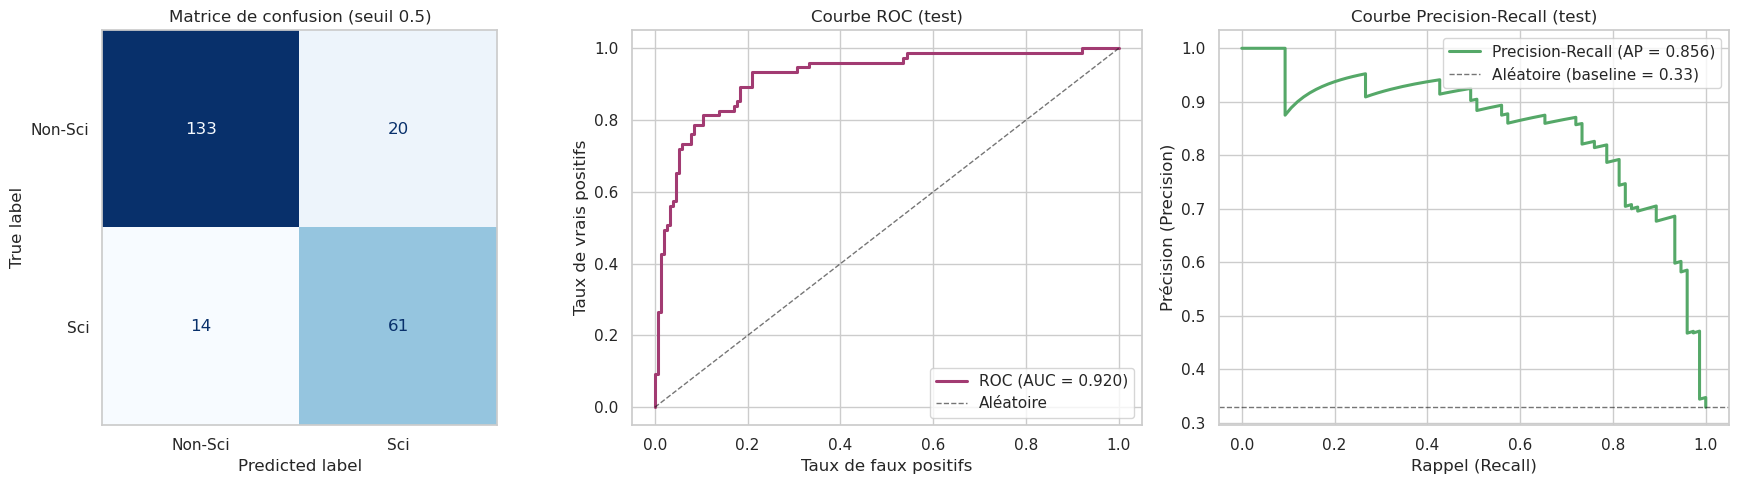

In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Entraînement du pipeline final sur tout le train
best_pipeline.fit(X_train_text, y_train)
y_score_test = best_pipeline.predict_proba(X_test_text)[:, 1]
y_pred       = (y_score_test >= BEST_THRESHOLD).astype(int)

# ── Métriques ───────────────────────────────────────────────────────────────
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auc   = roc_auc_score(y_test, y_score_test)
brier = brier_score_loss(y_test, y_score_test)
ap    = average_precision_score(y_test, y_score_test)  # v8 : ajout AP

print(f'\n{"="*65}')
print(f'ÉVALUATION FINALE — {best_model_name} | Stratégie : {strategy}')
print(f'{"="*65}')

print(classification_report(y_test, y_pred,
                             target_names=['Non-Scientific', 'Scientific'],
                             digits=3))

# ── Matrice de confusion + ROC + Precision-Recall (guide §4.2.3) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Non-Sci', 'Sci'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matrice de confusion (seuil {BEST_THRESHOLD})')
axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, y_score_test)
tn, fp, fn, tp = cm.ravel()
axes[1].plot(fpr, tpr, lw=2.2, color='#A23B72', label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Aléatoire')
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC (test)')
axes[1].legend(loc='lower right')

# Precision-Recall — recommandée pour classe minoritaire (guide §4.2.3)
pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_score_test)
baseline = y_test.mean()
axes[2].plot(pr_rec, pr_prec, lw=2.2, color='#55A868',
             label=f'Precision-Recall (AP = {ap:.3f})')
axes[2].axhline(baseline, color='k', ls='--', lw=1, alpha=0.6,
                label=f'Aléatoire (baseline = {baseline:.2f})')
axes[2].set_xlabel('Rappel (Recall)')
axes[2].set_ylabel('Précision (Precision)')
axes[2].set_title('Courbe Precision-Recall (test)')
axes[2].legend(loc='upper right')

plt.tight_layout(); plt.show()


**Interprétation de la matrice de confusion, de la courbe ROC et de la courbe Précision-Rappel :**

---

**Rapport de classification :**

- Classe **Non-Scientifique** : précision = 0,905 et rappel = 0,869. Le classifieur est fiable sur la classe majoritaire : il retrouve 87 % des vrais tweets non-scientifiques, et quand il prédit NON-SCI il a raison dans 90 % des cas.
- Classe **Scientifique** : précision = 0,753 et rappel = 0,813. Le rappel est satisfaisant (81 % des tweets scientifiques sont détectés), mais la précision plus faible (75 %) indique que 25 % des tweets prédits SCI sont en réalité NON-SCI.
- **Accuracy globale = 0,851** : cohérente avec le déséquilibre, mais le F1 macro = 0,834 est plus représentatif des performances réelles sur les deux classes.



**Matrice de confusion :**

La matrice se lit ainsi :
- **133 vrais négatifs** : tweets NON-SCI correctement classés
- **61 vrais positifs** : tweets SCI correctement détectés
- **20 faux positifs** : tweets NON-SCI classés à tort comme SCI
- **14 faux négatifs** : tweets SCI manqués par le classifieur

Les **14 faux négatifs** sont les erreurs les plus critiques : ce sont des tweets scientifiques que le classifieur n'a pas su détecter. Si l'objectif applicatif est de ne rater aucun contenu scientifique, on pourrait abaisser le seuil de décision (actuellement à 0,5) pour augmenter le rappel au prix d'une précision légèrement réduite.



**Courbe ROC (AUC = 0,920) :**

La courbe ROC monte rapidement vers le coin supérieur gauche, loin de la diagonale aléatoire. L'AUC de 0,920 indique que le classifieur sépare correctement les deux classes dans 92 % des cas, quel que soit le seuil de décision. C'est un très bon résultat pour un corpus de cette taille.



**Courbe Précision-Rappel (AP = 0,856) :**

L'AP de 0,856 est nettement supérieure à la baseline aléatoire (0,33 — proportion de tweets SCI dans le corpus). La courbe reste haute jusqu'à un rappel d'environ 0,8, puis descend : au-delà, pour détecter les derniers tweets scientifiques, le classifieur commence à faire davantage de faux positifs. Ce compromis précision-rappel est à ajuster selon les besoins : privilégier le rappel (ne rien manquer) ou la précision (être sûr de ce qu'on prédit).


## 11. Courbes d'apprentissage — diagnostic biais/variance

Les courbes d'apprentissage montrent l'évolution du F1 en fonction de la taille du jeu d'apprentissage, à la fois sur le train et en validation croisée.

**Comment interpréter ces courbes :**
- Si F1 train >> F1 validation avec un écart stable : le classifieur souffre de **sur-apprentissage** (variance élevée). Il mémorise le jeu d'apprentissage sans généraliser. Remède : plus de données, régularisation plus forte, modèle plus simple.
- Si F1 train ≈ F1 validation mais tous deux faibles : le classifieur souffre de **sous-apprentissage** (biais élevé). Il manque de capacité. Remède : modèle plus complexe, représentation plus riche.
- Si F1 validation converge vers F1 train quand la taille augmente : comportement sain, le classifieur bénéficierait de données supplémentaires.

> **Remarque**  
> Pour les pipelines avec sampler (`ImbPipeline`), la fonction `learning_curve` de scikit-learn ne peut pas être utilisée directement car le sampler modifie la taille du fold d'apprentissage à chaque itération. On utilise donc une boucle manuelle.


Learning curves — Logistic Regression (stratégie: class_weight)
Boucle manuelle (ImbPipeline incompatible avec learning_curve sklearn)


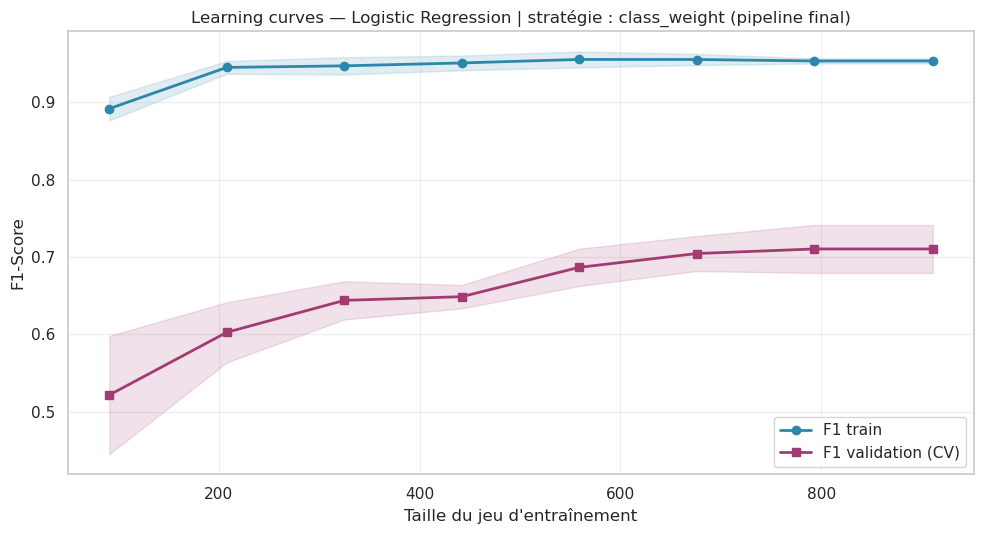


Écart final train - validation : 0.243


In [38]:
print(f'Learning curves — {best_model_name} (stratégie: {strategy})')
print('Boucle manuelle (ImbPipeline incompatible avec learning_curve sklearn)')

from sklearn.model_selection import StratifiedShuffleSplit

train_sizes_fracs = np.linspace(0.1, 1.0, 8)
train_sizes_n     = np.unique(
    np.array([max(10, int(r * len(y_train))) for r in train_sizes_fracs])
)

lc_train_scores = []
lc_val_scores   = []

for n in train_sizes_n:
    fold_train, fold_val = [], []
    for train_idx, val_idx in cv.split(X_train_text, y_train):
        X_fold = np.array(X_train_text)[train_idx]
        y_fold = y_train[train_idx]
        # Sous-échantillonnage stratifié du fold train à n exemples
        if n < len(y_fold):
            sss = StratifiedShuffleSplit(
                n_splits=1, train_size=n, random_state=RANDOM_STATE)
            sub_idx, _ = next(sss.split(X_fold, y_fold))
            X_fold, y_fold = X_fold[sub_idx], y_fold[sub_idx]
        X_val = np.array(X_train_text)[val_idx]
        y_val = y_train[val_idx]
        pipe_lc = build_final_pipeline(best_model_name, params)
        pipe_lc.fit(X_fold, y_fold)
        fold_train.append(f1_score(y_fold, pipe_lc.predict(X_fold),  zero_division=0))
        fold_val.append(  f1_score(y_val,  pipe_lc.predict(X_val),   zero_division=0))
    lc_train_scores.append(fold_train)
    lc_val_scores.append(fold_val)

train_scores_arr = np.array(lc_train_scores)
val_scores_arr   = np.array(lc_val_scores)
train_mean = train_scores_arr.mean(axis=1); train_std = train_scores_arr.std(axis=1)
val_mean   = val_scores_arr.mean(axis=1);   val_std   = val_scores_arr.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(train_sizes_n, train_mean, 'o-', color='#2E86AB', lw=2, label='F1 train')
ax.fill_between(train_sizes_n, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2E86AB')
ax.plot(train_sizes_n, val_mean, 's-', color='#A23B72', lw=2, label='F1 validation (CV)')
ax.fill_between(train_sizes_n, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#A23B72')
ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel('F1-Score')
ax.set_title(f'Learning curves — {best_model_name} | stratégie : {strategy} (pipeline final)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'\nÉcart final train - validation : {gap:.3f}')



**Interprétation des courbes d'apprentissage :**

On observe un **écart persistant** entre F1 train (proche de 1,0) et F1 validation (autour de 0,70-0,71) : c'est la signature d'un **sur-apprentissage modéré**. Le classifieur performe très bien sur les données qu'il a vues, mais généralise moins bien sur les folds de validation.

Cet écart est attendu pour une Régression Logistique avec `class_weight='balanced'` sur des données TF-IDF sparse : le modèle ajuste précisément ses coefficients sur le vocabulaire du fold d'apprentissage, certains tokens très discriminants dans un fold ne l'étant pas autant dans les autres.

Bonne nouvelle : la courbe de validation **progresse** quand la taille du jeu d'apprentissage augmente, et elle ne se stabilise pas complètement à 911 exemples. Cela indique que le classifieur **bénéficierait de données supplémentaires** pour continuer à progresser.

L'écart final train-validation de 0,243 reste acceptable pour un corpus de cette taille (environ 1 000 tweets). Avec un corpus plus grand ou des représentations plus riches (embeddings de type SciBERT), on pourrait espérer réduire cet écart.


In [39]:
from joblib import dump

# Refit on all data
X_all = np.concatenate([np.array(X_train_text), np.array(X_test_text)])
y_all = np.concatenate([y_train, y_test])

final_pipeline = build_final_pipeline(best_model_name, params)
final_pipeline.fit(X_all, y_all)

# Save
filename = 'final_model.joblib'
dump(final_pipeline, filename)
print("Modèle sauvegardé dans", filename)

Modèle sauvegardé dans final_model.joblib


In [40]:
from joblib import load
pipeline = load('final_model.joblib')
pipeline.predict([preprocess_p2("cancer risk study")])

array([1])

## 12. Conclusion

Ce pipeline de classification SCI vs NON-SCI suit une démarche logique : exploration des données, prétraitement, séparation apprentissage/test, comparaison de classifieurs, optimisation des hyperparamètres avec optuna, et évaluation finale.

Le prétraitement P2  a été retenu après comparaison sur le score de silhouette et les performances en validation croisée. La **Régression Logistique** avec `class_weight='balanced'` et des n-grammes jusqu'à l'ordre 3 est le classifieur le plus performant : F1 = 0,782 sur la classe SCI, accuracy = 0,851, AUC = 0,920 sur le jeu de test.

Les courbes d'apprentissage indiquent un écart train-validation de 0,243, signe de sur-apprentissage modéré. Davantage de données permettraient de réduire cet écart et améliorerait les résultats 
